# Проект: Предсказание успеваемости студентов

## Задачи проекта

1. **Регрессия** – предсказать итоговый средний балл студента (`final_gpa`).
2. **Классификация** – предсказать, сдаст ли студент курс (`pass_fail`).

## Данные

Датасет `student_performance_sample.csv` содержит 87 002 записи и 52 признака, включая:
- Оценки по предметам (math_score, science_score, english_score, …)
- Показатели посещаемости, учебной нагрузки, демографические данные, факторы образа жизни.
- Целевые переменные: `final_gpa` (числовая, от 0 до 4) и `pass_fail` (бинарная: 1 – сдал, 0 – не сдал).

## План работы

1. Загрузка и подготовка данных.
2. Создание трёх наборов признаков:
   - **A** – все 50 признаков (кроме целевых).
   - **B** – топ-15 признаков по корреляции с `final_gpa`.
   - **C** – минимальный набор из 7 ключевых признаков.
3. **Обучение моделей:**
   - Регрессия: `Linear Regression`, `Decision Tree Regressor`, `Random Forest Regressor`.
   - Классификация: `Logistic Regression`, `K‑Nearest Neighbors (KNN)`.
4. Сравнение качества моделей на каждом наборе признаков.
5. Выводы.

---

##1. Импорт библиотек

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Настройки отображения
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Загрузка данных
df = pd.read_csv("/content/student_performance_sample.csv")
print("Размер датасета:", df.shape)
df.head()

Размер датасета: (87002, 52)


,math_score,science_score,english_score,history_score,computer_score,attendance_rate,assignment_avg,quiz_avg,project_score,previous_gpa,...,final_gpa,standardized_exam_score,improvement_next_term,dropout_risk_score,learning_efficiency,stress_index,pass_fail,honors_flag,at_risk_flag,top_performer_flag
0,65.310905,70.146540,64.637100,52.224330,73.340195,0.633400,48.359974,56.693844,47.018936,2.692807,...,1.609431,50.729187,-0.684299,0.839020,1.392650,5.529143,1.0,0.0,1.0,0.0
1,36.286922,47.365112,63.186413,41.584972,41.860780,0.836677,61.242977,22.827354,34.573696,2.153198,...,1.083469,27.296108,-1.282218,0.995692,3.280873,5.738412,0.0,0.0,1.0,0.0
2,44.350006,49.276770,60.113940,66.770260,69.232600,0.416368,13.086650,50.505650,36.582474,2.195707,...,1.639738,45.395847,-0.171009,0.980274,-3.736717,1.464143,0.0,0.0,1.0,0.0
3,38.986053,53.321312,56.127403,45.804020,45.724130,0.798968,47.867245,56.748280,69.494860,1.783688,...,2.232290,49.549920,1.147010,0.024177,-2.385876,4.855495,0.0,0.0,1.0,0.0
4,49.436090,61.914436,62.451660,52.564953,55.699657,0.563033,33.520992,49.032593,60.029823,1.945506,...,2.091708,33.673218,0.162321,0.311174,-1.948544,1.191011,0.0,0.0,1.0,0.0


## Очистим датасет от возможных пропусков

In [15]:
# Проверка пропусков до очистки
#print("Пропуски до очистки:")
#print(df.isnull().sum())
print(f"Всего пропущенных значений: {df.isnull().sum().sum()}")

# Удаляем строки, содержащие хотя бы один пропуск
df = df.dropna()

# Проверка после очистки
print("\nПропуски после очистки:")
print(df.isnull().sum().sum())
print(f"Размер данных после удаления пропусков: {df.shape}")

Всего пропущенных значений: 0

Пропуски после очистки:
0
Размер данных после удаления пропусков: (87001, 52)


## Определение целевых переменных
Мы выбрали целевыми переменными `final_gpa` и `pass_fail`.

Количество признаков: 50
Распределение целевой переменной классификации:
 pass_fail
1.0    0.805922
0.0    0.194078
Name: proportion, dtype: float64


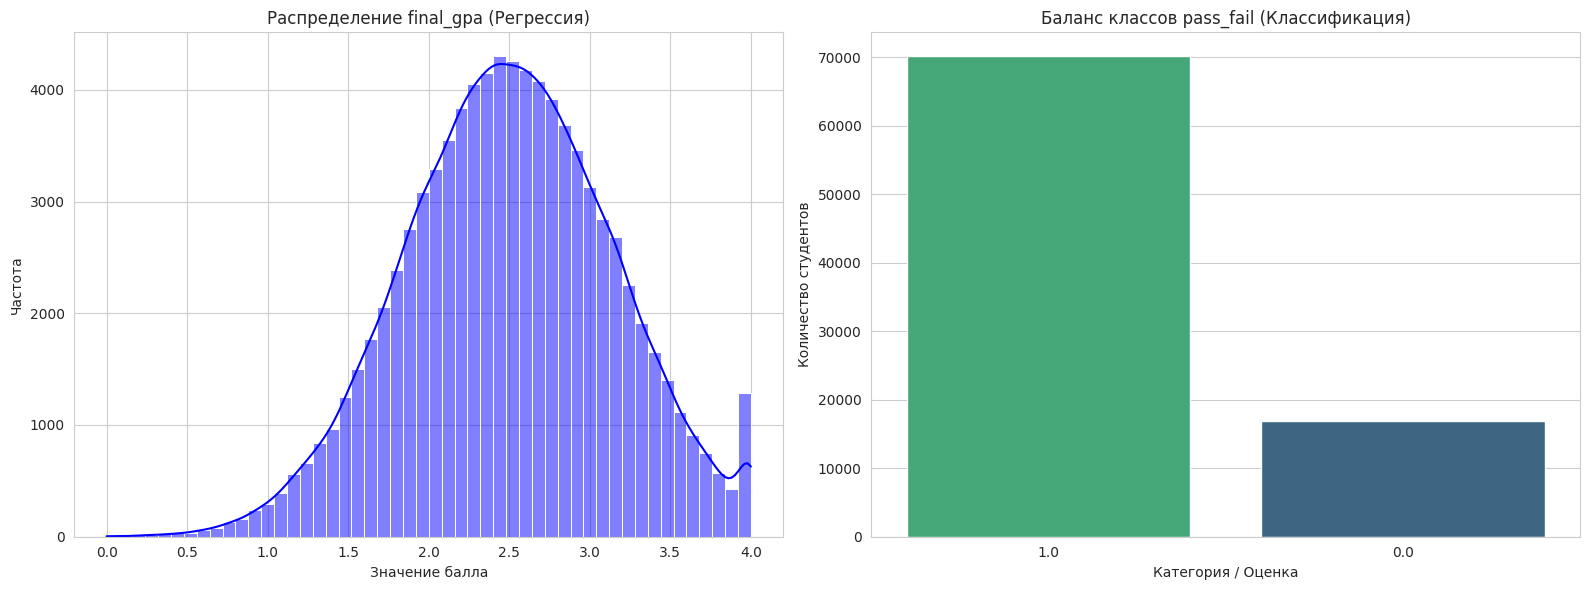

In [30]:
# Целевые переменные
target_reg = 'final_gpa'
target_clf = 'pass_fail'

# Список всех признаков (все колонки, кроме двух целевых)
feature_cols = [col for col in df.columns if col not in [target_reg, target_clf]]
X_all = df[feature_cols]
y_reg = df[target_reg]
y_clf = df[target_clf]

print("Количество признаков:", X_all.shape[1])
print("Распределение целевой переменной классификации:\n", y_clf.value_counts(normalize=True))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График для регрессии
sns.histplot(df[target_reg], bins=50, kde=True, color='blue', ax=axes[0])
axes[0].set_title(f'Распределение {target_reg} (Регрессия)')
axes[0].set_xlabel('Значение балла')
axes[0].set_ylabel('Частота')

# График для классификации
sns.countplot(data=df, x=target_clf, hue=target_clf, palette='viridis', ax=axes[1], order=df[target_clf].value_counts().index, legend=False)
axes[1].set_title(f'Баланс классов {target_clf} (Классификация)')
axes[1].set_xlabel('Категория / Оценка')
axes[1].set_ylabel('Количество студентов')

plt.tight_layout()
plt.show()

## Создаём наборы признаков
Из соображений здравого смысла будем рассматривать наборы с признаками, которые сильнее всего коллерируют с `final_gpa`.

In [17]:
X_A = X_all.copy()# A

# Вычисляем корреляцию (абсолютную) и берём 15 наибольших
corr_with_target = df[feature_cols + [target_reg]].corr()[target_reg].drop(target_reg).abs()
top15_features = corr_with_target.sort_values(ascending=False).head(15).index.tolist()
print("Топ-15 признаков:\n", top15_features)
X_B = df[top15_features].copy()# B

# Выбираем 7 наиболее значимых (на основе корреляции и здравого смысла)
minimal_features = [
    'standardized_exam_score',
    'computer_score',
    'math_score',
    'science_score',
    'previous_gpa',
    'attendance_rate',
    'study_hours_daily'
]
# Проверяем, что все столбцы существуют
minimal_features = [f for f in minimal_features if f in df.columns]
print("\nМинимальный набор признаков:\n", minimal_features)
X_C = df[minimal_features].copy()#C

print(f"\nРазмеры наборов: A={X_A.shape[1]}, B={X_B.shape[1]}, C={X_C.shape[1]}")

Топ-15 признаков:
 ['standardized_exam_score', 'computer_score', 'math_score', 'science_score', 'english_score', 'previous_gpa', 'quiz_avg', 'digital_literacy', 'coding_practice_hours', 'history_score', 'lms_login_frequency', 'at_risk_flag', 'honors_flag', 'attendance_rate', 'revision_hours']

Минимальный набор признаков:
 ['standardized_exam_score', 'computer_score', 'math_score', 'science_score', 'previous_gpa', 'attendance_rate', 'study_hours_daily']

Размеры наборов: A=50, B=15, C=7


## Вспомогательные функции

In [18]:
def evaluate_regression(X, y, models, use_scaler=True):
    """
    Обучает модели регрессии на train/test, возвращает словарь с метриками.
    use_scaler – применять StandardScaler (рекомендуется для линейной регрессии).
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    if use_scaler:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    else:
        X_train = X_train.values
        X_test = X_test.values

    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    return results

def evaluate_classification(X, y, models, use_scaler=True):
    """
    Обучает модели классификации на train/test, возвращает словарь с метриками.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    if use_scaler:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    else:
        X_train = X_train.values
        X_test = X_test.values

    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        # ROC-AUC (только если есть predict_proba)
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
            roc = roc_auc_score(y_test, y_prob)
        else:
            roc = None
        results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC-AUC': roc}
    return results

## Обучение и сравнение
Для регрессии будем использовать следующие модели:
- Linear Regression
- Decision Tree
- Random Forest

In [19]:
# Модели регрессии
reg_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100)
}

# Словарь для хранения результатов
reg_results = {}

# Перебираем наборы признаков
for name, X in zip(['A (all features)', 'B (top 15)', 'C (minimal)'], [X_A, X_B, X_C]):
    print(f"\n=== Регрессия | Набор: {name} ===")
    res = evaluate_regression(X, y_reg, reg_models, use_scaler=True)
    reg_results[name] = res
    # Вывод в виде таблицы
    df_res = pd.DataFrame(res).T
    print(df_res.round(4))
    print("-" * 50)


=== Регрессия | Набор: A (all features) ===
                      MAE    RMSE      R2
Linear Regression  0.2574  0.3223  0.7486
Decision Tree      0.3822  0.4847  0.4316
Random Forest      0.2604  0.3283  0.7392
--------------------------------------------------

=== Регрессия | Набор: B (top 15) ===
                      MAE    RMSE      R2
Linear Regression  0.2881  0.3609  0.6849
Decision Tree      0.4110  0.5205  0.3445
Random Forest      0.2880  0.3624  0.6823
--------------------------------------------------

=== Регрессия | Набор: C (minimal) ===
                      MAE    RMSE      R2
Linear Regression  0.3167  0.3966  0.6195
Decision Tree      0.4566  0.5723  0.2076
Random Forest      0.3258  0.4073  0.5986
--------------------------------------------------


##Визуализация и сравнение результатов регрессии

Сводка результатов регрессии:

        Feature Set              Model     MAE    RMSE      R²
0  A (all features)  Linear Regression  0.2574  0.3223  0.7486
1  A (all features)      Decision Tree  0.3822  0.4847  0.4316
2  A (all features)      Random Forest  0.2604  0.3283  0.7392
3        B (top 15)  Linear Regression  0.2881  0.3609  0.6849
4        B (top 15)      Decision Tree  0.4110  0.5205  0.3445
5        B (top 15)      Random Forest  0.2880  0.3624  0.6823
6       C (minimal)  Linear Regression  0.3167  0.3966  0.6195
7       C (minimal)      Decision Tree  0.4566  0.5723  0.2076
8       C (minimal)      Random Forest  0.3258  0.4073  0.5986


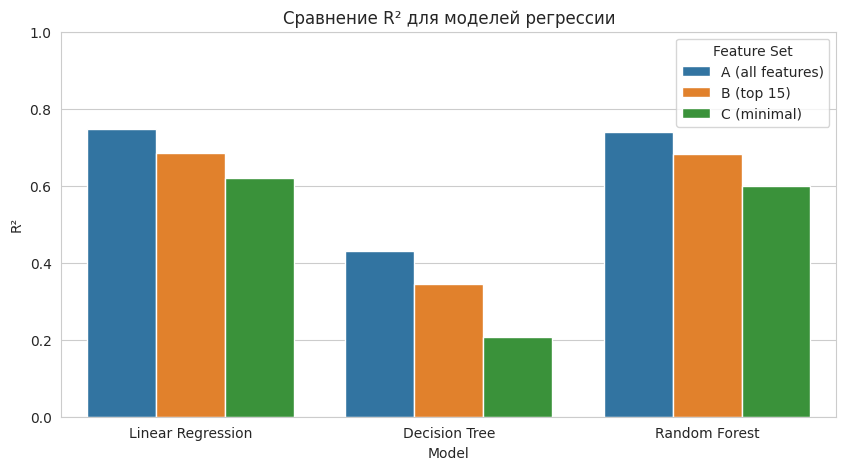

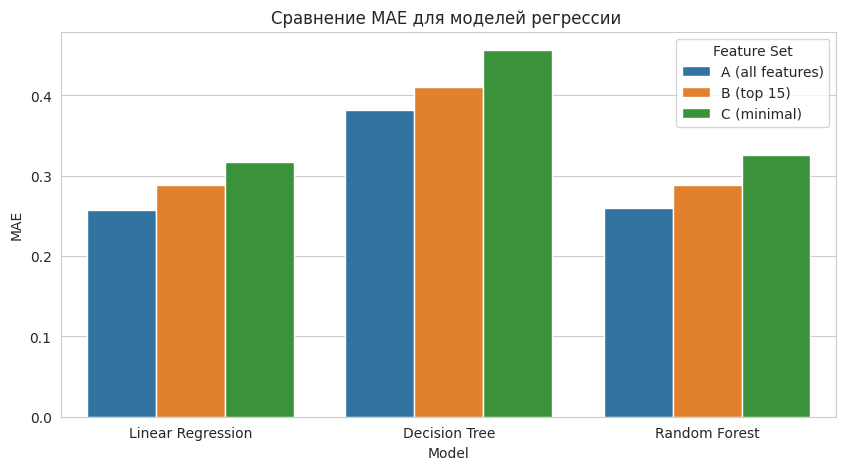

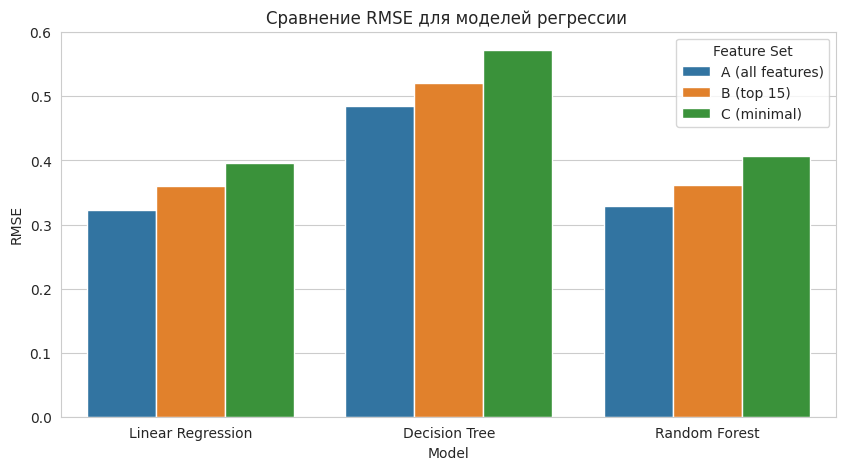

In [39]:
# Сводная таблица для всех наборов
summary_reg = []
for feat_set, res_dict in reg_results.items():
    for model_name, metrics in res_dict.items():
        summary_reg.append({
            'Feature Set': feat_set,
            'Model': model_name,
            'MAE': metrics['MAE'],
            'RMSE': metrics['RMSE'],
            'R²': metrics['R2']
        })
df_summary_reg = pd.DataFrame(summary_reg)
print("Сводка результатов регрессии:\n")
print(df_summary_reg.round(4))

# График сравнения R²
plt.figure(figsize=(10, 5))
sns.barplot(data=df_summary_reg, x='Model', y='R²', hue='Feature Set')
plt.title('Сравнение R² для моделей регрессии')
plt.ylim(0, 1)
plt.legend(title='Feature Set')
plt.show()

# График сравнения MAE (чем меньше, тем лучше)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_summary_reg, x='Model', y='MAE', hue='Feature Set')
plt.title('Сравнение MAE для моделей регрессии ')
plt.legend(title='Feature Set')
plt.show()

# График сравнения RMSE (чем меньше, тем лучше)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_summary_reg, x='Model', y='RMSE', hue='Feature Set')
plt.title('Сравнение RMSE для моделей регрессии ')
plt.legend(title='Feature Set')
plt.show()

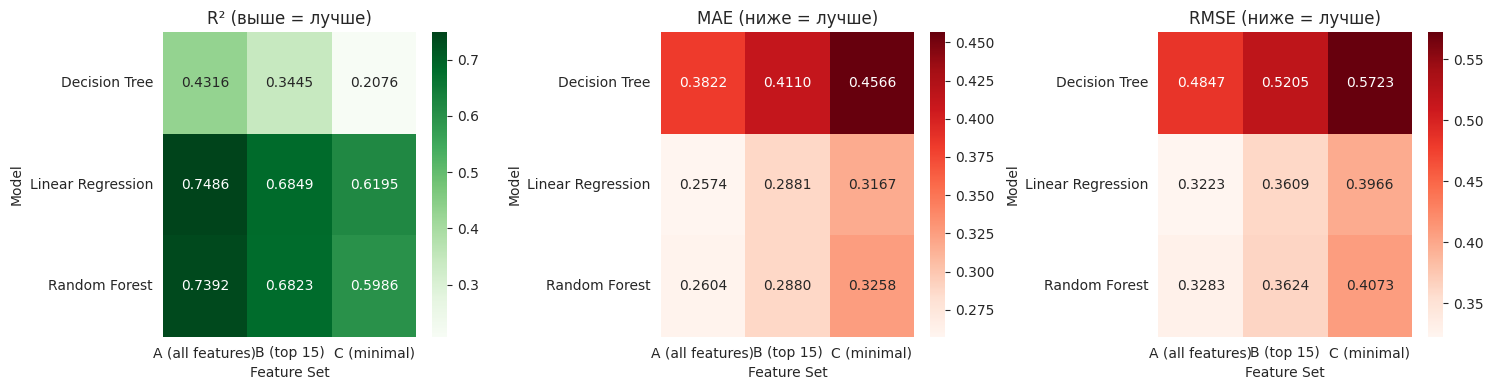

In [40]:
# Pivot-таблицы для тепловых карт
pivot_r2 = df_summary_reg.pivot(index='Model', columns='Feature Set', values='R²')
pivot_mae = df_summary_reg.pivot(index='Model', columns='Feature Set', values='MAE')
pivot_rmse = df_summary_reg.pivot(index='Model', columns='Feature Set', values='RMSE')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(pivot_r2, annot=True, cmap='Greens', fmt='.4f', ax=axes[0])
axes[0].set_title('R² (выше = лучше)')

sns.heatmap(pivot_mae, annot=True, cmap='Reds', fmt='.4f', ax=axes[1])
axes[1].set_title('MAE (ниже = лучше)')

sns.heatmap(pivot_rmse, annot=True, cmap='Reds', fmt='.4f', ax=axes[2])
axes[2].set_title('RMSE (ниже = лучше)')

plt.tight_layout()
plt.show()

Сравнение

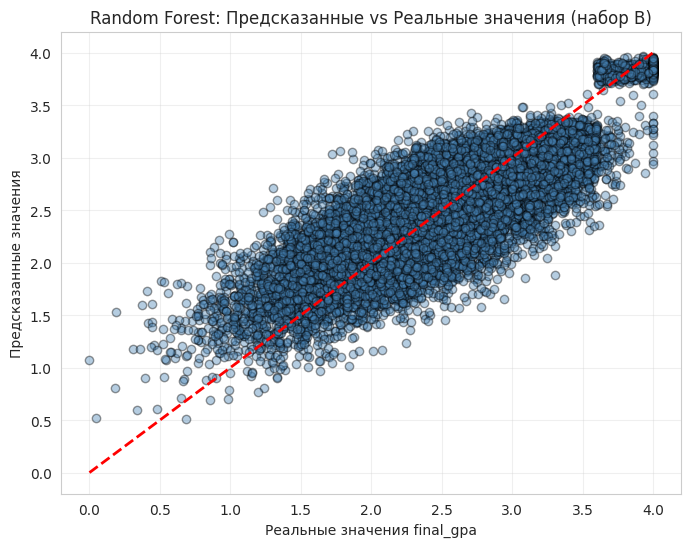

In [43]:
# Выбираем лучшую модель регрессии (на основе R² на наборе B)
best_reg_model = RandomForestRegressor(random_state=42, n_estimators=100)
scaler_reg = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X_B, y_reg, test_size=0.2, random_state=42)
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

best_reg_model.fit(X_train_scaled, y_train)
y_pred_best = best_reg_model.predict(X_test_scaled)

# График "предсказанные vs реальные"
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4, edgecolors='k', color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальные значения final_gpa')
plt.ylabel('Предсказанные значения')
plt.title('Random Forest: Предсказанные vs Реальные значения (набор B)')
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_5387/1390584366.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')


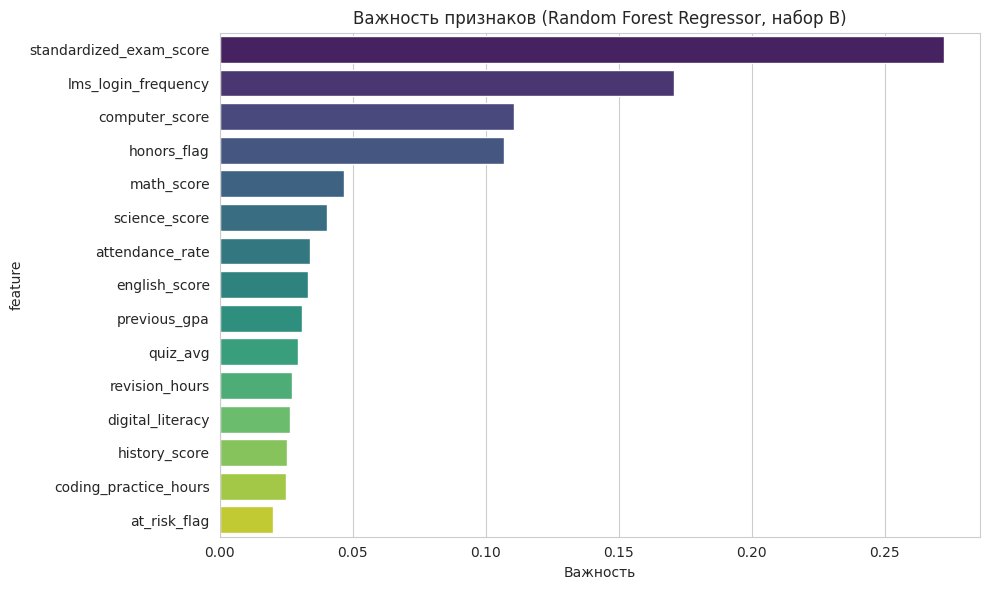

Топ-5 важнейших признаков:
                feature  importance
standardized_exam_score    0.272284
    lms_login_frequency    0.170757
         computer_score    0.110735
            honors_flag    0.106921
             math_score    0.046905


In [33]:
# Важность признаков для лучшей модели (набор B)
feature_importance = pd.DataFrame({
    'feature': X_B.columns,
    'importance': best_reg_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Важность признаков (Random Forest Regressor, набор B)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

print("Топ-5 важнейших признаков:")
print(feature_importance.head(5).to_string(index=False))

## Выводы по регрессии

- **Random Forest** показывает наилучшие результаты на всех наборах признаков.
- Набор B (топ‑15) не так сильно уступает полному набору A, но значительно проще.
- Сильнее всего влияет признак `standart_exam_score`.

**Рекомендация:** использовать Random Forest на наборе B.

##Визуализация и сравнение результатов классификации
Модели:
- Logistic Regression
- KNN

In [22]:
# Модели классификации
clf_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

clf_results = {}

for name, X in zip(['A (all features)', 'B (top 15)', 'C (minimal)'], [X_A, X_B, X_C]):
    print(f"\n=== Классификация | Набор: {name} ===")
    res = evaluate_classification(X, y_clf, clf_models, use_scaler=True)
    clf_results[name] = res
    df_res = pd.DataFrame(res).T
    # Округляем метрики
    print(df_res.round(4))
    print("-" * 50)


=== Классификация | Набор: A (all features) ===
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.9982     0.9989  0.9989  0.9989   1.0000
KNN                    0.9376     0.9491  0.9749  0.9618   0.9661
--------------------------------------------------

=== Классификация | Набор: B (top 15) ===
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.9979     0.9999  0.9974  0.9987   1.0000
KNN                    0.9659     0.9809  0.9766  0.9788   0.9887
--------------------------------------------------

=== Классификация | Набор: C (minimal) ===
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.9995     0.9996  0.9997  0.9997   1.0000
KNN                    0.9699     0.9768  0.9861  0.9814   0.9921
--------------------------------------------------


Сводка результатов классификации:

        Feature Set                Model  Accuracy  Precision  Recall      F1  \
0  A (all features)  Logistic Regression    0.9982     0.9989  0.9989  0.9989   
1  A (all features)                  KNN    0.9376     0.9491  0.9749  0.9618   
2        B (top 15)  Logistic Regression    0.9979     0.9999  0.9974  0.9987   
3        B (top 15)                  KNN    0.9659     0.9809  0.9766  0.9788   
4       C (minimal)  Logistic Regression    0.9995     0.9996  0.9997  0.9997   
5       C (minimal)                  KNN    0.9699     0.9768  0.9861  0.9814   

   ROC-AUC  
0   1.0000  
1   0.9661  
2   1.0000  
3   0.9887  
4   1.0000  
5   0.9921  


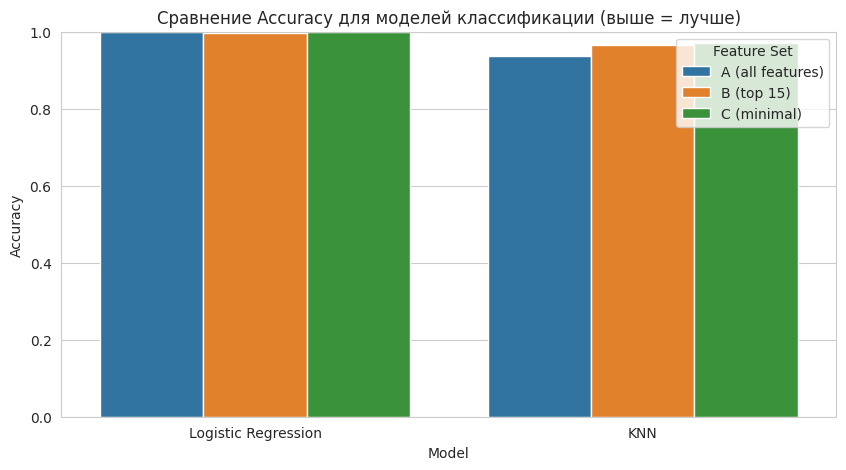

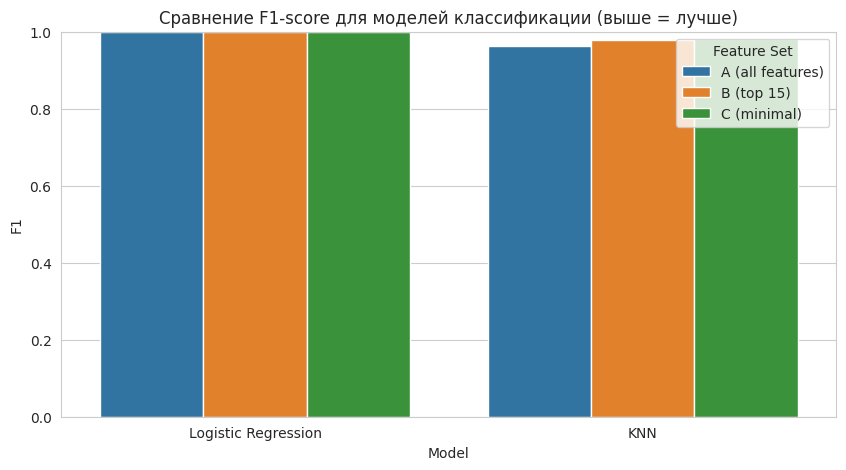

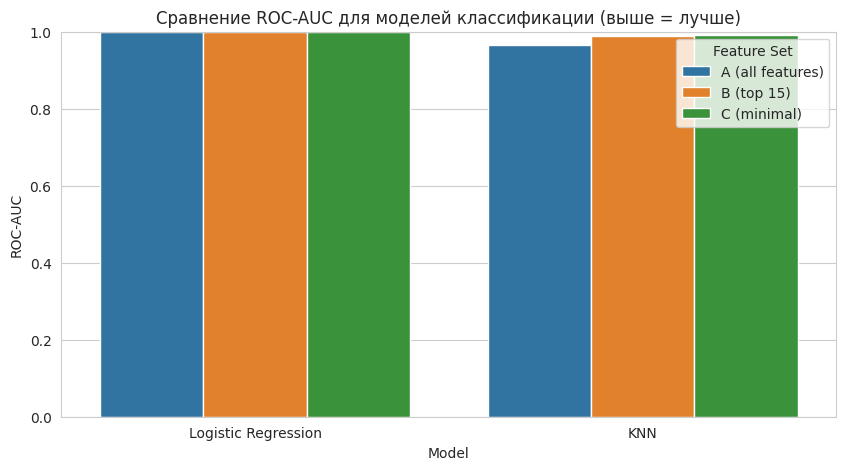

In [45]:
# Сводная таблица классификации
summary_clf = []
for feat_set, res_dict in clf_results.items():
    for model_name, metrics in res_dict.items():
        summary_clf.append({
            'Feature Set': feat_set,
            'Model': model_name,
            'Accuracy': metrics['Accuracy'],
            'Precision': metrics['Precision'],
            'Recall': metrics['Recall'],
            'F1': metrics['F1'],
            'ROC-AUC': metrics['ROC-AUC']
        })
df_summary_clf = pd.DataFrame(summary_clf)
print("Сводка результатов классификации:\n")
print(df_summary_clf.round(4))

# Accuracy
plt.figure(figsize=(10, 5))
sns.barplot(data=df_summary_clf, x='Model', y='Accuracy', hue='Feature Set')
plt.title('Сравнение Accuracy для моделей классификации (выше = лучше)')
plt.ylim(0, 1)
plt.legend(title='Feature Set')
plt.show()

# F1-score
plt.figure(figsize=(10, 5))
sns.barplot(data=df_summary_clf, x='Model', y='F1', hue='Feature Set')
plt.title('Сравнение F1-score для моделей классификации (выше = лучше)')
plt.ylim(0, 1)
plt.legend(title='Feature Set')
plt.show()

# ROC-AUC
plt.figure(figsize=(10, 5))
sns.barplot(data=df_summary_clf, x='Model', y='ROC-AUC', hue='Feature Set')
plt.title('Сравнение ROC-AUC для моделей классификации (выше = лучше)')
plt.ylim(0, 1)
plt.legend(title='Feature Set')
plt.show()

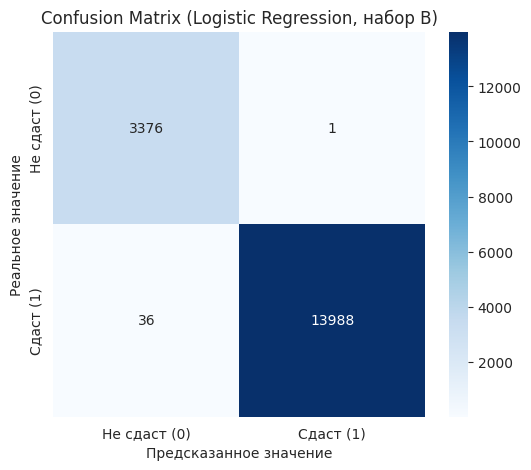

In [44]:
# Выбираем лучшую модель классификации (Logistic Regression на наборе B)
best_clf_model = LogisticRegression(random_state=42, max_iter=1000)
scaler_clf = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X_B, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled = scaler_clf.transform(X_test)

best_clf_model.fit(X_train_scaled, y_train)
y_pred_clf = best_clf_model.predict(X_test_scaled)

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_clf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не сдаст (0)', 'Сдаст (1)'],
            yticklabels=['Не сдаст (0)', 'Сдаст (1)'])
plt.title('Confusion Matrix (Logistic Regression, набор B)')
plt.ylabel('Реальное значение')
plt.xlabel('Предсказанное значение')
plt.show()

# Подробная классификационная статистика
#print("Classification Report:")
#print(classification_report(y_test, y_pred_clf, target_names=['Не сдаст', 'Сдаст']))

/tmp/ipykernel_5387/3612677380.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='coefficient', y='feature', palette='coolwarm')


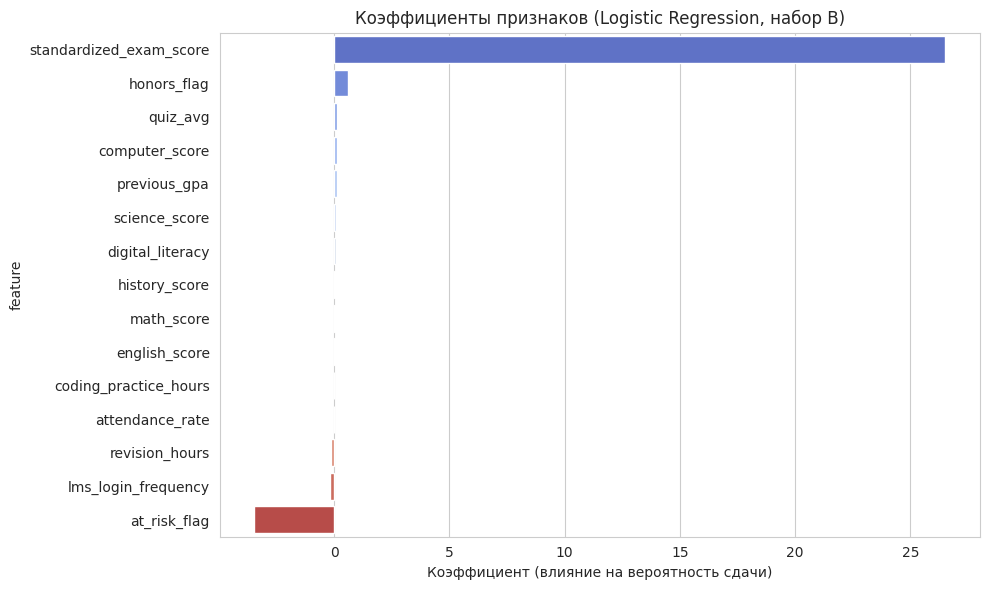

In [36]:
# Коэффициенты логистической регрессии (набор B)
coef_df = pd.DataFrame({
    'feature': X_B.columns,
    'coefficient': best_clf_model.coef_[0]
}).sort_values('coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='coefficient', y='feature', palette='coolwarm')
plt.title('Коэффициенты признаков (Logistic Regression, набор B)')
plt.xlabel('Коэффициент (влияние на вероятность сдачи)')
plt.tight_layout()
plt.show()

## Выводы:
### Регрессия

- **Random Forest** показывает наилучшие результаты на всех наборах признаков.
- Набор B (топ‑15) не так сильно уступает полному набору A, но значительно проще.
- Важнейшие признаками дляRandom Forest стали:
   -  `standardized_exam_score`
   - `lms_login_frequency`  
   - `computer_score`   
   - `honors_flag`  
   - `math_score`

### Классификация
- Лучше себя показала по всем метрикам модель **Logistic Regression**
- Значения метрик близки к 1 что показывает качество работы модели.